In [1]:
import torch, numpy as np
from botorch.test_functions.multi_fidelity import AugmentedHartmann, AugmentedBranin
from botorch.test_functions.multi_fidelity import AugmentedRosenbrock
#, BoreholeMultiFidelity, WingWeightMultiFidelity
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.acquisition.utils import project_to_target_fidelity
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.optim import optimize_acqf
from torch.distributions.normal import Normal
from botorch import fit_gpytorch_mll
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.acquisition import PosteriorMean
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
import warnings
warnings.filterwarnings('ignore')
from botorch.acquisition.acquisition import AcquisitionFunction
from botorch.acquisition.analytic import AnalyticAcquisitionFunction
from torch.distributions.normal import Normal
import torch
from typing import Callable
from __future__ import annotations
from botorch.utils.transforms import t_batch_mode_transform
import time
import gpytorch

tkwargs = {"dtype": torch.double, "device": "cpu"}
device = torch.device("cpu")
dtype = torch.double

In [2]:
def make_cost_fn_from_dict(cost_dict: dict[float, float],
                           *,
                           dtype: torch.dtype = torch.double,
                           device: torch.device | None = None):
    """
    Build a nearest-neighbour cost function from a {fidelity: cost} table.
    Robust to float precision; no dict lookups from tensor floats.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1) Create a stable, Python-float list once
    klist = sorted(float(k) for k in cost_dict.keys())
    vlist = [float(cost_dict[k]) for k in klist]

    # 2) Turn them into tensors
    keys = torch.tensor(klist, dtype=dtype, device=device)   # (K,)
    vals = torch.tensor(vlist, dtype=dtype, device=device)   # (K,)

    # 3) Nearest-neighbour lookup (handles batched s)
    def cost_fn(s: torch.Tensor) -> torch.Tensor:
        k = keys.to(device=s.device, dtype=s.dtype)
        v = vals.to(device=s.device, dtype=s.dtype)
        idx = (s.unsqueeze(-1) - k).abs().argmin(dim=-1)     # same shape as s
        return v[idx]                                        # (...,)

    return cost_fn


In [3]:


torch.set_default_dtype(torch.double)   # everything created afterwards is float64
# ------------------------------------------------------------
#  Cost-aware multi-fidelity EI  (analytic, requires q = 1)
# ------------------------------------------------------------
class MFEI(AnalyticAcquisitionFunction):
    """
    Stage value  (for one candidate x,s):
        EI_hi(x) * ρ((x,s), (x,s_hi)) * cost(s_hi)/cost(s)

    where EI_hi is analytic EI at the target fidelity s_hi.
    """

    def __init__(
        self,
        model,
        fid_dim: int,
        target_fidelity: float,
        cost_fn: Callable[[torch.Tensor], torch.Tensor],
        best_f: float,                          # <-- NEW
        eps: float = 1e-9,
        posterior_transform=None,
        debug: bool = False,
        max_debug_calls: int = 6,
        **kwargs,
    ):
        super().__init__(model=model, posterior_transform=posterior_transform)
        self.fid_dim      = int(fid_dim)
        self.s_hi         = float(target_fidelity)
        self.cost_fn      = cost_fn
        self.best_f       = float(best_f)
        self.eps          = eps
        self._dbg         = debug
        self._dbg_count   = 0
        self._dbg_limit   = int(max_debug_calls)

        # standard normal for EI formula
        self._std_normal = torch.distributions.Normal(
            torch.zeros(1, dtype=model.train_targets.dtype, device=model.train_targets.device),
            torch.ones (1, dtype=model.train_targets.dtype, device=model.train_targets.device),
        )

    # ------------ helper: safe split, works for any batch depth -------- #
    @staticmethod
    def _split_design(X, fid_dim: int):
        return X[..., :-1], X[..., fid_dim]      # (..., d) , (...,)

    def _stats(self, name: str, t: torch.Tensor):
        """Print shape + basic stats – robust to empty tensors."""
        if not self._dbg:
            return
        s = f"{name:10}  shape={tuple(t.shape)}"
        if t.numel() == 0:                      # <-- guard
            print(s + "  EMPTY")
            return
        with torch.no_grad():
            s += (f"  min={float(t.min()):.3e}  max={float(t.max()):.3e}  "
                f"nan={(~torch.isfinite(t)).sum().item()}  "
                f"inf={(torch.isinf(t)).sum().item()})")
        print(s)


    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:

        if self._dbg:
            print(f"\n==== forward call {self._dbg_count} ====")
            self._dbg_count += 1
            self._stats("X in", X)

        # ---------- same maths as before ------------------------------ #
        X0  = X[..., 0, :]
        xd, s = X0[..., :-1], X0[..., self.fid_dim]

        s_hi = torch.full_like(s, self.s_hi)
        X_hi = torch.cat([xd, s_hi.unsqueeze(-1)], -1).unsqueeze(-2)
        X_s  = torch.cat([xd,   s .unsqueeze(-1)], -1).unsqueeze(-2)
        X_pair = torch.cat([X_s, X_hi], dim=-2)

        self._stats("X_pair", X_pair)

        # Single posterior call for both fidelities
        with gpytorch.settings.fast_pred_var(True):
            post_pair = self.model.posterior(
                X_pair,
                posterior_transform=self.posterior_transform,
                observation_noise=False,
            )

        # Means / variances for the two points
        mean2 = post_pair.mean.squeeze(-1)                              # (..., 2)
        mu_hi = mean2[..., 1]
        var2  = post_pair.variance.squeeze(-1).clamp_min(self.eps)  # (..., 2)       
        var_ss, var_hh = var2[..., 0], var2[..., 1]

        # Off-diagonal covariance Cov[(x,s), (x,s_hi)] via lazy cov if available
        mvn = post_pair.mvn
        # # if hasattr(mvn, "lazy_covariance_matrix"):

        # cov_sh = (
        #     mvn.lazy_covariance_matrix[..., 0:1, 1:2]
        #     .to_dense()
        #     .squeeze(-1).squeeze(-1)                                # (...,)
        # )

        # else:

        cov_sh = mvn.covariance_matrix[..., 0, 1]


        # Correlation ρ
        rho = (cov_sh / (var_ss.sqrt() * var_hh.sqrt())).clamp(-1.0, 1.0)

        self._stats("rho", rho)   # now prints shape=(64,) not (64,0)

        # Analytic EI at high fidelity using mu_hi, var_hh
        sigma = var_hh.sqrt()
        z     = (mu_hi - self.best_f) / sigma
        ei    = (mu_hi - self.best_f) * self._std_normal.cdf(z) + \
                sigma * torch.exp(self._std_normal.log_prob(z))

        self._stats("EI", ei)

        # cost ratio
        cost_ratio = self.cost_fn(s_hi) / self.cost_fn(s)
        self._stats("cost ratio", cost_ratio)

        # final value (no squeezing / patching)
        val = ei.squeeze(-1) * (rho) * (cost_ratio)
        self._stats("val", val)

        return val



In [4]:

def draw_initial(f,
                 n: int = 20,
                 s_choices = None,
                 probs     = None,
                 flag_two_fid: bool = False):
    """
    Generate an initial design.

    flag_two_fid = False  -> layout [x_part , s]
    flag_two_fid = True   -> layout [x_part , s_fixed=1.0 , s_var]
    """

    dim_x = f.dim - 2 if flag_two_fid else f.dim - 1
    bounds = f.bounds.clone().to(dtype=dtype, device=device)

    # ------------------------------------------------------------------#
    # 1) scale the design variables to their physical bounds
    # ------------------------------------------------------------------#
    low  = bounds[0, :dim_x]        #  (dim_x,)
    high = bounds[1, :dim_x]

    u      = torch.rand(n, dim_x, dtype=torch.double, device=device)
    x_part = low + (high - low) * u             # (n , dim_x)

    # ------------------------------------------------------------------#
    # 2) sample the fidelity / fidelities
    # ------------------------------------------------------------------#
    if s_choices is None:
        s_choices = [1.0] if not flag_two_fid else [0.3, 0.7, 1.0]
    if probs is None:
        probs = [1.0 / len(s_choices)] * len(s_choices)

    s_choices_t = torch.tensor(s_choices, dtype=torch.double, device=device)
    probs_t     = torch.tensor(probs,     dtype=torch.double, device=device)
    s_sample    = s_choices_t[
        torch.multinomial(probs_t, n, replacement=True)
    ].unsqueeze(-1)                 # (n , 1)

    # ------------------------------------------------------------------#
    # 3) build the full X matrix
    # ------------------------------------------------------------------#
    if flag_two_fid:
        s_fixed = torch.full((n, 1), 1.0, dtype=torch.double, device=device)
        X0 = torch.cat([x_part, s_fixed, s_sample], dim=-1)   # (n , dim_x+2)
    else:
        X0 = torch.cat([x_part, s_sample], dim=-1)            # (n , dim_x+1)

    Y0 = f(X0).unsqueeze(-1)
    return X0, Y0



def fit_mf_gp(X: torch.Tensor, Y: torch.Tensor, fid_dim) -> SingleTaskMultiFidelityGP:
    model = SingleTaskMultiFidelityGP(
        train_X=X, train_Y=Y,
        data_fidelities=[fid_dim],
        outcome_transform=Standardize(m=1),
    ).to(dtype=torch.double, device=device)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model


In [5]:
# ------------------------------------------------------------
#  Cost-aware 1-step MF-EI experiment – single run
# ------------------------------------------------------------
import torch, math, warnings, time, pandas as pd
import matplotlib.pyplot as plt
from typing import Sequence
from __future__ import annotations
from typing import Callable
from botorch.test_functions.multi_fidelity import AugmentedHartmann
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from botorch.optim.optimize import optimize_acqf, optimize_acqf_mixed
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch import fit_gpytorch_mll


# ------------------------------------------------------------------
#  Main routine
# ------------------------------------------------------------------
def run_cost_aware_mfei_bo_once(
    f: Callable,
    T: int = 30,
    init_n: int = 8,
    s_hi: float = 1.0,
    s_choices = [0.01, 0.1, 1.0],
    probs = [0.4, 0.3, 0.3],
    cost_dict: dict | None = None,
    seed: int | None = None,
    per_run_plots: bool = True,
    flag_two_fid: bool = False,
    fixed_initial_data_by_seed: dict | None = None,
):
    """
    One multi-fidelity EI run, cost-aware.

    Returns dict with keys:
        cum_cost, best_hi, rec_mu, rec_iters_points, rec_mu_points,
        last_rec_mu, last_rec_x
    """
    if cost_dict is None:
        cost_dict = {0.2: 0.87, 0.75: 1.07, 1.0: 1.25}
    #print("Using costs:", cost_dict)
    cost_fn = make_cost_fn_from_dict(cost_dict)
    if seed is not None:
        torch.manual_seed(int(seed))


    def sim_cost(s: float) -> float:
        return cost_dict[s]

    if flag_two_fid:
        dim_x   = f.dim - 2
        fid_var = f.dim - 1          # <-- 1 varying fidelity (3)
        fid_fix = f.dim - 2          # <-- 1 fixed fidelity   (2)
        d_total = f.dim
        bounds = f.bounds.clone().detach().to(**tkwargs)
        fid_dim = fid_var
    else:
        dim_x   = f.dim - 1
        fid_dim = f.dim - 1
        d_total = f.dim
        bounds = f.bounds.clone().detach().to(**tkwargs)


    fixed_init = get_fixed_initial_xy_for_seed(seed, fixed_initial_data_by_seed)
    if fixed_init is None:
        X, Y = draw_initial(f, init_n, s_choices=s_choices, probs=probs, flag_two_fid=flag_two_fid)
    else:
        X, Y = fixed_init
        if X.shape[-1] != d_total:
            raise ValueError(
                f"Precomputed X has dim {X.shape[-1]}, expected {d_total} for this benchmark."
            )
        print(
            f"Using precomputed initial X,Y for seed={int(seed)} with {X.shape[0]} high-fidelity points"
        )
    # print("Initial design matrix X:\n", X)
    # print("Initial responses Y:\n", Y.squeeze(-1))

    # ------------------------------------------------------------------
    #  Trackers
    # ------------------------------------------------------------------
    iter_idx, y_at_iter, s_at_iter = [], [], []
    cum_cost_hist, best_hi_hist    = [], []

    #  ---- initial GP + recommendation ----
    model = fit_mf_gp(X, Y, fid_dim)

    total_cost = 0.0
    prev_best = float("-inf")

    # ------------------------------------------------------------------
    #  BO loop
    # ------------------------------------------------------------------
    for t in range(T):
        
        #  ---- initial GP + recommendation ----
        model = fit_mf_gp(X, Y, fid_dim)

        # 2) Current best at high fidelity
        hf_mask = X[:, fid_dim] == s_hi

        y_max = Y[hf_mask].max() 


        best_f_value = float(y_max.item())

        acqf = MFEI(
            model      = model,
            fid_dim    = fid_dim,
            target_fidelity = s_hi,
            cost_fn  = cost_fn,
            best_f     = best_f_value,
            debug=False,
            debug_every=150
        )

        if flag_two_fid:
            fixed_features_list = [{fid_fix: 1.0, fid_var: float(s)} for s in s_choices] #for rosenbrock
        else:
            fixed_features_list = [{fid_dim: float(s)} for s in s_choices]
        new_x, _ = optimize_acqf_mixed(
            acq_function        = acqf,
            bounds              = bounds,
            q                   = 1,
            num_restarts        = 12,
            raw_samples         = 256,
            fixed_features_list = fixed_features_list,
        )
        new_x = new_x                   # (1, d) row tensor
        new_y = f(new_x).view(1, 1)          # (1, 1)

        # 4) Book-keeping
        s_val = new_x[0, fid_dim].item()
        cost_t = sim_cost(s_val)
        total_cost += cost_t
        cum_cost_hist.append(total_cost)
        iter_idx.append(t + 1)
        y_at_iter.append(new_y.item())
        s_at_iter.append(s_val)

        X = torch.cat([X, new_x], dim=0)
        Y = torch.cat([Y, new_y], dim=0)

        hf_mask = X[:, fid_dim] == s_hi
        if hf_mask.any():
            prev_best = Y[hf_mask].max().item()
        current_best = prev_best                  # forward-filled value
        best_hi_hist.append(current_best)

        # 1) Re-fit GP
        model = fit_mf_gp(X, Y, fid_dim)

        # Progress print
        if t%5 == 0 or t == T-1:
            print(
                f"Iter {t+1:02d} | s={s_val:.3f} | y={new_y.item():.6f} "
                f"| cost={cost_t:.3f} | cum_cost={total_cost:.3f} "
                f"| best_hf={current_best:.6f}"
            )

    # ------------------------------------------------------------------
    #  Plots
    # ------------------------------------------------------------------
    if per_run_plots:

        # (4) Cumulative cost vs best high fidelity
        plt.figure()
        plt.plot(cum_cost_hist, best_hi_hist, linewidth=1)
        plt.xlabel("Cumulative cost"); plt.ylabel("Best observed @ s=1.0")
        plt.title("Best high fidelity vs cumulative cost"); plt.grid(True)

        plt.show()

    # ------------------------------------------------------------------
    #  Return results
    # ------------------------------------------------------------------
    return {
        "cum_cost":           cum_cost_hist,      # [T]
        "best_hi":            best_hi_hist,       # [T]
    }


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tests import SuzukiMFEmulator
from tests import AugmentedBukin, AugmentedRastrigin,AugmentedAckley

# Set these to True when you want to reuse the precomputed high-fidelity
# initial X, Y from the cleaned seed files instead of calling draw_initial(...).
USE_PRECOMPUTED_ACKLEY_HF_INIT = True
USE_PRECOMPUTED_RASTRIGIN_HF_INIT = True
USE_PRECOMPUTED_BUKIN_HF_INIT = True
USE_PRECOMPUTED_SUZUKI_HF_INIT = True

PRECOMPUTED_INIT_DIR = Path.cwd() / 'precomputed_hf_init'

def resolve_precomputed_hf_init_path(*names: str) -> Path:
    for name in names:
        candidate = PRECOMPUTED_INIT_DIR / name
        if candidate.exists():
            return candidate
    tried = ', '.join(str(PRECOMPUTED_INIT_DIR / name) for name in names)
    raise FileNotFoundError(f'Precomputed init file not found. Tried: {tried}')

PRECOMPUTED_ACKLEY_HF_INIT_PATH = resolve_precomputed_hf_init_path(
    'ackley_hf_init_by_seed.txt',
)
PRECOMPUTED_RASTRIGIN_HF_INIT_PATH = resolve_precomputed_hf_init_path(
    'rastrigin_hf_init_by_seed.txt',
)
PRECOMPUTED_BUKIN_HF_INIT_PATH = resolve_precomputed_hf_init_path(
    'bukin_hf_init_by_seed.txt',
)
PRECOMPUTED_SUZUKI_HF_INIT_PATH = resolve_precomputed_hf_init_path(
    'suzuki_hf_init_by_seed.txt',
)

def load_precomputed_hf_init_from_txt(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f'Precomputed init file not found: {path}')
    raw = json.loads(path.read_text())
    return {int(seed): value for seed, value in raw.items()}

PRECOMPUTED_ACKLEY_HF_INIT_BY_SEED = load_precomputed_hf_init_from_txt(
    PRECOMPUTED_ACKLEY_HF_INIT_PATH
)
PRECOMPUTED_RASTRIGIN_HF_INIT_BY_SEED = load_precomputed_hf_init_from_txt(
    PRECOMPUTED_RASTRIGIN_HF_INIT_PATH
)
PRECOMPUTED_BUKIN_HF_INIT_BY_SEED = load_precomputed_hf_init_from_txt(
    PRECOMPUTED_BUKIN_HF_INIT_PATH
)
PRECOMPUTED_SUZUKI_HF_INIT_BY_SEED = load_precomputed_hf_init_from_txt(
    PRECOMPUTED_SUZUKI_HF_INIT_PATH
)

def get_fixed_initial_xy_for_seed(seed: int | None, fixed_initial_data_by_seed: dict | None):
    if fixed_initial_data_by_seed is None or seed is None:
        return None
    item = fixed_initial_data_by_seed.get(int(seed))
    if item is None:
        return None
    X = torch.tensor(item['X'], **tkwargs)
    Y = torch.tensor(item['Y'], **tkwargs)
    return X, Y


# --------------------------------------------------------------------------
# Make sure everything below this comment is defined or imported *above*:
#   draw_initial, fit_mf_gp, f, bounds, fid_dim, best_hi_so_far,
#   _normalize_vf_and_args, CostAwareMFEI, make_cost_fn_from_dict,
#   run_cost_aware_mf_bo_once
# --------------------------------------------------------------------------

def run_single(f, seed: int, total_iters: int = 35):
    """Run a single BO experiment and return a DataFrame of its trajectory."""

    fixed_initial_data_by_seed = None

    # -------------------------------------------------------
    # pick defaults based on the *type* of f
    # -------------------------------------------------------
    if isinstance(f, AugmentedHartmann):
        # cost_dict = {0.3: 1.05, 0.7: 1.25, 1.0: 1.40}
        # s_choices = [0.3, 0.7, 1.0]
        # probs     = [0.5, 0.3, 0.2]
        cost_dict = {1.0: 6}
        s_choices = [1.0]   
        probs     = [1.0]
        flag_two_fid = False
        s_hi      = 1.0
    elif isinstance(f, AugmentedAckley):
        # cost_dict = {0.3: 1.05, 0.7: 1.25, 1.0: 1.40}
        # s_choices = [0.3, 0.7, 1.0]
        # probs     = [0.5, 0.3, 0.2]
        cost_dict = {1.0: 6}  
        s_choices = [1.0] 
        probs     = [1.0]
        flag_two_fid = False          # ← only one fidelity col in Branin
        s_hi      = 1.0
        if USE_PRECOMPUTED_ACKLEY_HF_INIT:
            fixed_initial_data_by_seed = PRECOMPUTED_ACKLEY_HF_INIT_BY_SEED

    elif isinstance(f, AugmentedBranin):
        # cost_dict = {0.3: 1.05, 0.7: 1.25, 1.0: 1.40}
        # s_choices = [0.3, 0.7, 1.0]
        # probs     = [0.5, 0.3, 0.2]
        cost_dict = {1.0: 6}  
        s_choices = [1.0] 
        probs     = [1.0]
        flag_two_fid = False          # ← only one fidelity col in Branin
        s_hi      = 1.0

    elif isinstance(f, AugmentedRastrigin):
        cost_dict = {1.0: 6}   #0.3: 1.05, 0.7: 1.25,
        s_choices = [1.0]    #0.3, 0.7,
        probs     = [1.0]   #0.5, 0.3, 0.2
        # cost_dict = {0.8: 5, 1.0: 11}
        # s_choices = [0.8, 1.0]
        # probs     = [0.6, 0.4]
        flag_two_fid = False          # current tests.py Rastrigin has one fidelity col
        s_hi      = 1.0
        if USE_PRECOMPUTED_RASTRIGIN_HF_INIT:
            fixed_initial_data_by_seed = PRECOMPUTED_RASTRIGIN_HF_INIT_BY_SEED

    elif isinstance(f, AugmentedBukin):
        cost_dict = {1.0: 6}   #0.3: 1.05, 0.7: 1.25,
        s_choices = [1.0]    #0.3, 0.7,
        probs     = [1.0]   #0.5, 0.3, 0.2
        # cost_dict = {0.8: 5, 1.0: 11}
        # s_choices = [0.8, 1.0]
        # probs     = [0.6, 0.4]
        flag_two_fid = False          # current tests.py Bukin has one fidelity col
        s_hi      = 1.0
        if USE_PRECOMPUTED_BUKIN_HF_INIT:
            fixed_initial_data_by_seed = PRECOMPUTED_BUKIN_HF_INIT_BY_SEED

    elif isinstance(f, SuzukiMFEmulator):
        cost_dict = {1.0: 6}  
        s_choices = [1.0] 
        probs     = [1.0]
        flag_two_fid = False
        s_hi         = 1.0
        if USE_PRECOMPUTED_SUZUKI_HF_INIT:
            fixed_initial_data_by_seed = PRECOMPUTED_SUZUKI_HF_INIT_BY_SEED


    else:
        raise ValueError("Unknown function; supply cost_dict, s_choices, probs manually")

    # -------------------------------------------------------
    # run the BO loop with those settings
    # -------------------------------------------------------
    results = run_cost_aware_mfei_bo_once(
        f=f,
        T=total_iters,
        init_n=8,
        s_hi=s_hi,
        cost_dict=cost_dict,
        s_choices=s_choices,
        probs=probs,
        seed=seed,
        per_run_plots=True,
        flag_two_fid=flag_two_fid,
        fixed_initial_data_by_seed=fixed_initial_data_by_seed,
    )

    df = pd.DataFrame({
        "iteration":       np.arange(1, len(results["cum_cost"]) + 1),
        "cumulative_cost": results["cum_cost"],
        "best_hi":         results["best_hi"],
    })
    return df


def aggregate_runs(dfs):
    """Stack per-run dataframes and compute mean & std."""
    merged = (
        pd.concat(
            {i: df.set_index("iteration") for i, df in enumerate(dfs)},
            names=["run", "iteration"],
        )
        .reset_index(level="run")
    )
    stats = (
        merged.groupby("iteration")
        .agg(["mean", "std"])  # adds a 2-level column index
    )
    # Flatten multi-index columns: e.g. ('cumulative_cost','mean') → 'cumulative_cost_mean'
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    return stats.reset_index()

def plot_with_band(iterations, mean, std, ylabel, title):
    plt.figure()
    # plt.ylim(3.251, 3.291)
    plt.plot(iterations, mean, lw=2, label="mean")
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.25, label="±1 σ")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def plot_best_vs_cost(cost_mean, cost_std, best_mean, best_std,
                      title="Best observed vs. cumulative cost (mean ± 1 σ)",
                      optimum_val=None):
    """
    Scatter-line plot of mean best-observed value vs mean cumulative cost,
    with a shaded ±1 σ region around the best value.
    """
    # sort by cost so the line is monotone
    order = np.argsort(cost_mean)
    cost_mean, best_mean = cost_mean.iloc[order], best_mean.iloc[order]
    best_std            = best_std.iloc[order]

    plt.figure()
    plt.plot(cost_mean, best_mean, lw=2, label="mean trajectory")
    plt.fill_between(cost_mean,
                     best_mean - best_std,
                     best_mean + best_std,
                     alpha=0.25,
                     label="±1 σ (best)")
    if optimum_val is not None:
        plt.axhline(optimum_val, ls="--", label=f"True optimum = {optimum_val}")

    plt.xlabel("Cumulative cost (mean)")
    plt.ylabel("Best observed hi-fidelity value (mean)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



=== Running ackley (iters=55) ===
Using precomputed initial X,Y for seed=33 with 6 high-fidelity points
Iter 01 | s=1.000 | y=-21.821005 | cost=6.000 | cum_cost=6.000 | best_hf=-20.154256
Iter 06 | s=1.000 | y=-20.037502 | cost=6.000 | cum_cost=36.000 | best_hf=-18.405472
Iter 11 | s=1.000 | y=-19.598069 | cost=6.000 | cum_cost=66.000 | best_hf=-18.405472
Iter 16 | s=1.000 | y=-19.464199 | cost=6.000 | cum_cost=96.000 | best_hf=-18.405472
Iter 21 | s=1.000 | y=-19.177989 | cost=6.000 | cum_cost=126.000 | best_hf=-18.405472
Iter 26 | s=1.000 | y=-20.092864 | cost=6.000 | cum_cost=156.000 | best_hf=-17.005160
Iter 31 | s=1.000 | y=-18.257199 | cost=6.000 | cum_cost=186.000 | best_hf=-17.005160
Iter 36 | s=1.000 | y=-19.804104 | cost=6.000 | cum_cost=216.000 | best_hf=-17.005160
Iter 41 | s=1.000 | y=-17.226090 | cost=6.000 | cum_cost=246.000 | best_hf=-17.005160
Iter 46 | s=1.000 | y=-16.466666 | cost=6.000 | cum_cost=276.000 | best_hf=-16.466666
Iter 51 | s=1.000 | y=-16.809050 | cost=

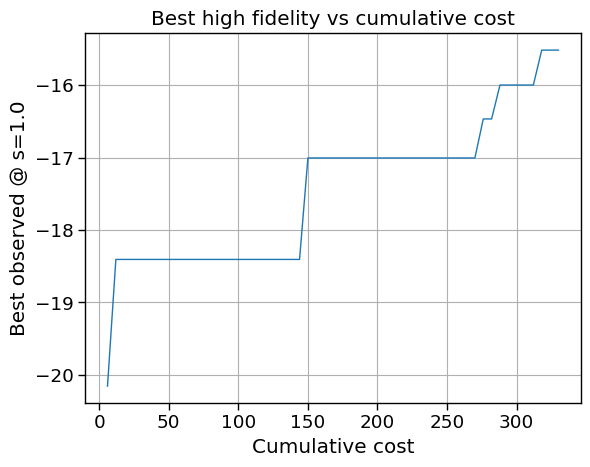

Using precomputed initial X,Y for seed=42 with 6 high-fidelity points
Iter 01 | s=1.000 | y=-20.700776 | cost=6.000 | cum_cost=6.000 | best_hf=-19.882644
Iter 06 | s=1.000 | y=-21.190401 | cost=6.000 | cum_cost=36.000 | best_hf=-19.882644
Iter 11 | s=1.000 | y=-20.207529 | cost=6.000 | cum_cost=66.000 | best_hf=-19.351011
Iter 16 | s=1.000 | y=-19.866604 | cost=6.000 | cum_cost=96.000 | best_hf=-19.351011
Iter 21 | s=1.000 | y=-20.949910 | cost=6.000 | cum_cost=126.000 | best_hf=-19.307960
Iter 26 | s=1.000 | y=-19.724200 | cost=6.000 | cum_cost=156.000 | best_hf=-19.307960
Iter 31 | s=1.000 | y=-20.484938 | cost=6.000 | cum_cost=186.000 | best_hf=-18.974806
Iter 36 | s=1.000 | y=-19.492833 | cost=6.000 | cum_cost=216.000 | best_hf=-18.974806
Iter 41 | s=1.000 | y=-18.982395 | cost=6.000 | cum_cost=246.000 | best_hf=-18.764591
Iter 46 | s=1.000 | y=-20.336596 | cost=6.000 | cum_cost=276.000 | best_hf=-18.236415
Iter 51 | s=1.000 | y=-20.522666 | cost=6.000 | cum_cost=306.000 | best_hf=

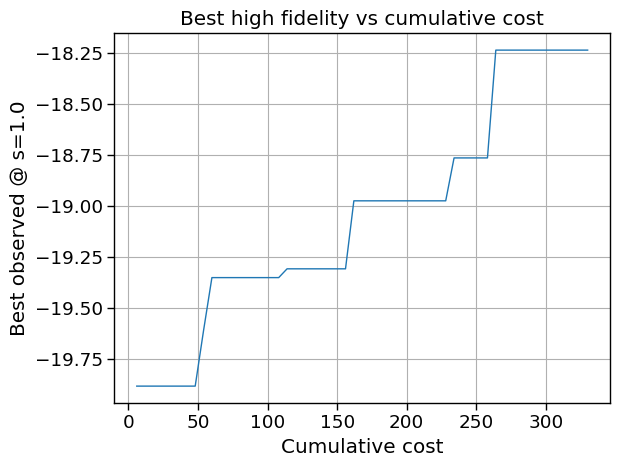

Using precomputed initial X,Y for seed=88 with 6 high-fidelity points
Iter 01 | s=1.000 | y=-19.845635 | cost=6.000 | cum_cost=6.000 | best_hf=-19.248186
Iter 06 | s=1.000 | y=-21.047213 | cost=6.000 | cum_cost=36.000 | best_hf=-19.248186
Iter 11 | s=1.000 | y=-19.225138 | cost=6.000 | cum_cost=66.000 | best_hf=-18.283906
Iter 16 | s=1.000 | y=-17.832146 | cost=6.000 | cum_cost=96.000 | best_hf=-17.357409
Iter 21 | s=1.000 | y=-20.920145 | cost=6.000 | cum_cost=126.000 | best_hf=-17.357409
Iter 26 | s=1.000 | y=-19.701623 | cost=6.000 | cum_cost=156.000 | best_hf=-17.357409
Iter 31 | s=1.000 | y=-19.976443 | cost=6.000 | cum_cost=186.000 | best_hf=-17.357409
Iter 36 | s=1.000 | y=-17.709996 | cost=6.000 | cum_cost=216.000 | best_hf=-17.357409
Iter 41 | s=1.000 | y=-18.035639 | cost=6.000 | cum_cost=246.000 | best_hf=-17.357409
Iter 46 | s=1.000 | y=-19.684961 | cost=6.000 | cum_cost=276.000 | best_hf=-17.357409
Iter 51 | s=1.000 | y=-19.282767 | cost=6.000 | cum_cost=306.000 | best_hf=

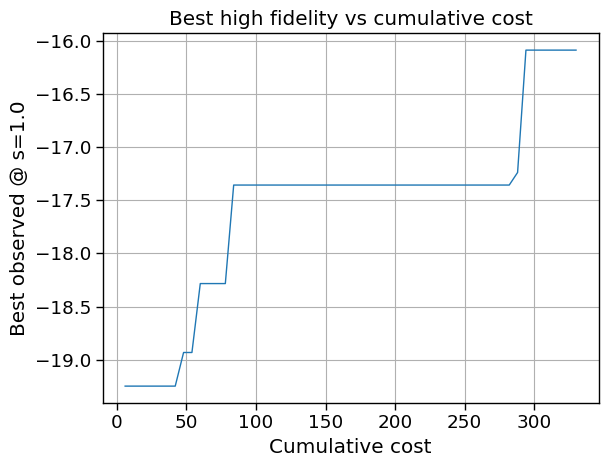

Using precomputed initial X,Y for seed=105 with 6 high-fidelity points
Iter 01 | s=1.000 | y=-20.696657 | cost=6.000 | cum_cost=6.000 | best_hf=-20.017054
Iter 06 | s=1.000 | y=-21.354378 | cost=6.000 | cum_cost=36.000 | best_hf=-20.017054
Iter 11 | s=1.000 | y=-19.898494 | cost=6.000 | cum_cost=66.000 | best_hf=-19.048973
Iter 16 | s=1.000 | y=-17.753204 | cost=6.000 | cum_cost=96.000 | best_hf=-17.753204
Iter 21 | s=1.000 | y=-18.356359 | cost=6.000 | cum_cost=126.000 | best_hf=-17.516504
Iter 26 | s=1.000 | y=-17.362090 | cost=6.000 | cum_cost=156.000 | best_hf=-17.362090
Iter 31 | s=1.000 | y=-14.149281 | cost=6.000 | cum_cost=186.000 | best_hf=-14.149281
Iter 36 | s=1.000 | y=-18.470181 | cost=6.000 | cum_cost=216.000 | best_hf=-14.149281
Iter 41 | s=1.000 | y=-15.012802 | cost=6.000 | cum_cost=246.000 | best_hf=-14.149281
Iter 46 | s=1.000 | y=-14.032447 | cost=6.000 | cum_cost=276.000 | best_hf=-14.032447
Iter 51 | s=1.000 | y=-17.792364 | cost=6.000 | cum_cost=306.000 | best_hf

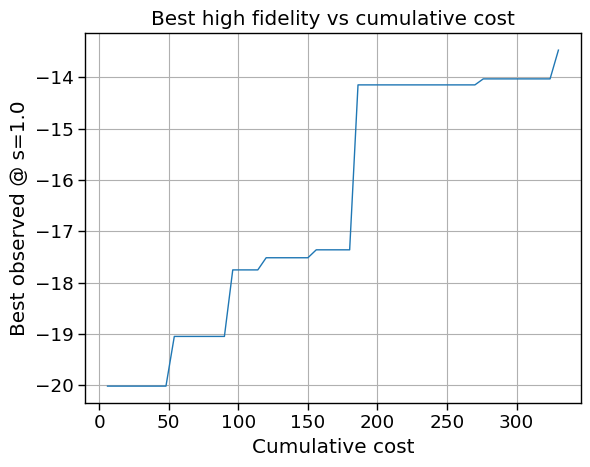

Using precomputed initial X,Y for seed=67 with 6 high-fidelity points
Iter 01 | s=1.000 | y=-20.170775 | cost=6.000 | cum_cost=6.000 | best_hf=-20.170775
Iter 06 | s=1.000 | y=-21.028611 | cost=6.000 | cum_cost=36.000 | best_hf=-18.988972
Iter 11 | s=1.000 | y=-19.570424 | cost=6.000 | cum_cost=66.000 | best_hf=-18.912915
Iter 16 | s=1.000 | y=-17.936649 | cost=6.000 | cum_cost=96.000 | best_hf=-17.936649
Iter 21 | s=1.000 | y=-20.055526 | cost=6.000 | cum_cost=126.000 | best_hf=-17.683902
Iter 26 | s=1.000 | y=-20.156779 | cost=6.000 | cum_cost=156.000 | best_hf=-17.683902
Iter 31 | s=1.000 | y=-21.113202 | cost=6.000 | cum_cost=186.000 | best_hf=-17.683902
Iter 36 | s=1.000 | y=-17.129495 | cost=6.000 | cum_cost=216.000 | best_hf=-17.129495
Iter 41 | s=1.000 | y=-16.110082 | cost=6.000 | cum_cost=246.000 | best_hf=-16.110082
Iter 46 | s=1.000 | y=-17.543682 | cost=6.000 | cum_cost=276.000 | best_hf=-15.671410
Iter 51 | s=1.000 | y=-16.922273 | cost=6.000 | cum_cost=306.000 | best_hf=

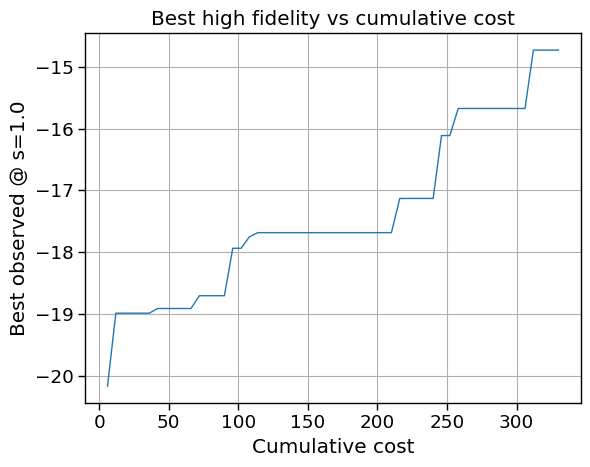

Using precomputed initial X,Y for seed=151 with 6 high-fidelity points
Iter 01 | s=1.000 | y=-20.990011 | cost=6.000 | cum_cost=6.000 | best_hf=-20.874857
Iter 06 | s=1.000 | y=-21.584035 | cost=6.000 | cum_cost=36.000 | best_hf=-19.848227
Iter 11 | s=1.000 | y=-20.066412 | cost=6.000 | cum_cost=66.000 | best_hf=-19.566844
Iter 16 | s=1.000 | y=-20.914032 | cost=6.000 | cum_cost=96.000 | best_hf=-19.566844
Iter 21 | s=1.000 | y=-20.363815 | cost=6.000 | cum_cost=126.000 | best_hf=-19.566844
Iter 26 | s=1.000 | y=-17.924736 | cost=6.000 | cum_cost=156.000 | best_hf=-17.924736
Iter 31 | s=1.000 | y=-19.156828 | cost=6.000 | cum_cost=186.000 | best_hf=-17.924736
Iter 36 | s=1.000 | y=-16.536787 | cost=6.000 | cum_cost=216.000 | best_hf=-16.536787
Iter 41 | s=1.000 | y=-19.169752 | cost=6.000 | cum_cost=246.000 | best_hf=-16.536787
Iter 46 | s=1.000 | y=-19.016731 | cost=6.000 | cum_cost=276.000 | best_hf=-16.536787
Iter 51 | s=1.000 | y=-19.790454 | cost=6.000 | cum_cost=306.000 | best_hf

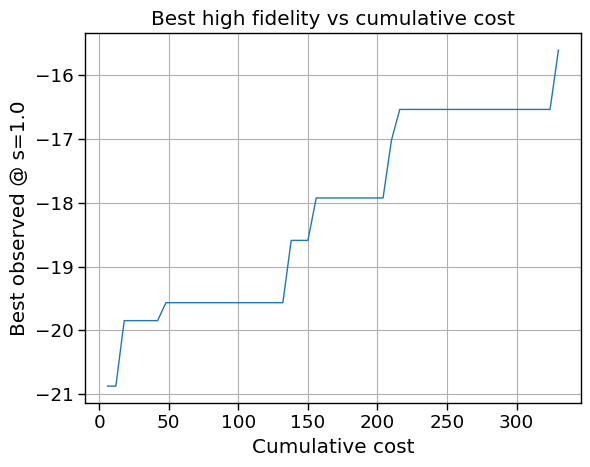

Saved aggregate stats → sf_ei_runs_ackley_aggregate.csv


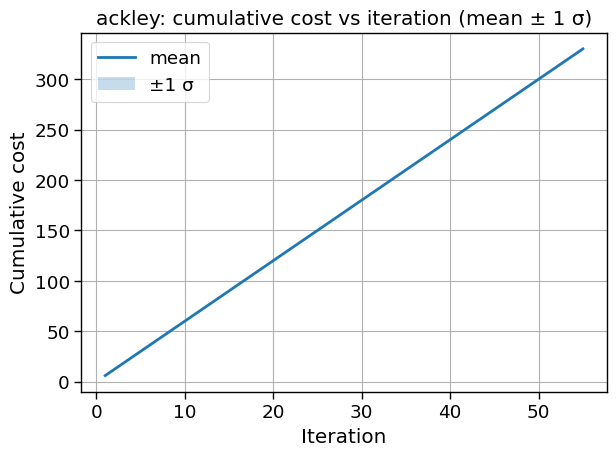

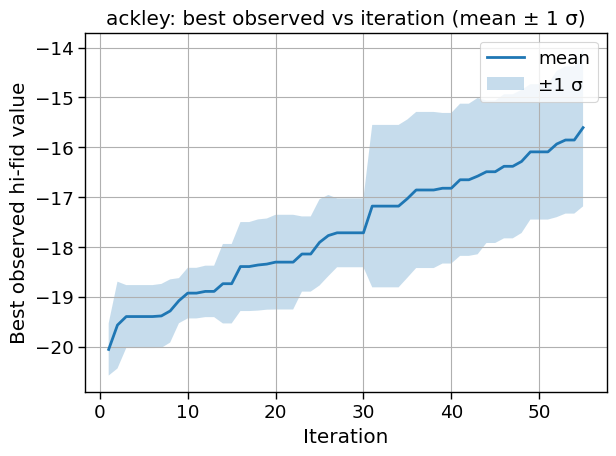

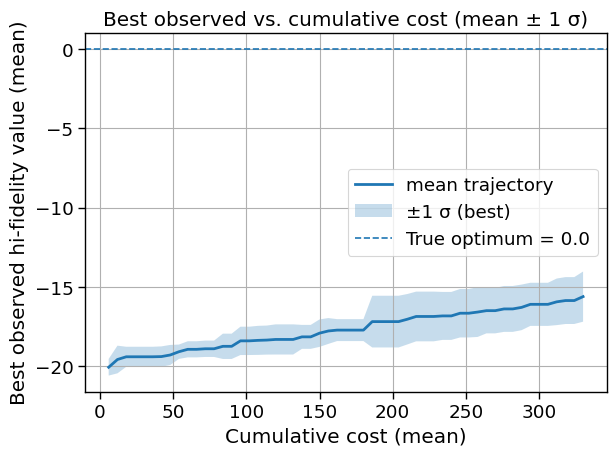

In [11]:
import matplotlib.pyplot as plt
from collections import OrderedDict


# ------------------------------------------------------------------
# 0)  Benchmarks and their custom settings
# ------------------------------------------------------------------
benchmarks = OrderedDict([
    # ("hartmann",   (AugmentedHartmann(negate=True), 60,  3.32237)),
    # ("branin",     (AugmentedBranin(negate=True), 50, -0.3978)),
    # ("suzuki_mf", (SuzukiMFEmulator(num_samples=32, stochastic=True), 60, None)),
    # ("bukin",      (AugmentedBukin(negate=True), 50, -0.0)),
    ("ackley",  (AugmentedAckley(dim=3, negate=True), 55,  0.0)),
    # ("rastrigin",  (AugmentedRastrigin(dim=3, negate=True), 50, -0.0)),
])


SEEDS = [ 33, 42, 88, 105, 67, 151,] # 5 runs each  

# ------------------------------------------------------------------
# 1)  Loop over benchmarks
# ------------------------------------------------------------------
for tag, (f, total_iters, opt_val) in benchmarks.items():
    print(f"\n=== Running {tag} (iters={total_iters}) ===")

    # 1a) independent runs
    run_dfs = [run_single(f=f, seed=s, total_iters=total_iters) for s in SEEDS]

    # 1b) aggregate & save
    stats_df = aggregate_runs(run_dfs)
    out_csv  = f"sf_ei_runs_{tag}_aggregate.csv"
    stats_df.to_csv(out_csv, index=False)
    print(f"Saved aggregate stats → {out_csv}")

    # 1c) plots
    iters = stats_df["iteration"]

    plot_with_band(
        iters,
        stats_df["cumulative_cost_mean"],
        stats_df["cumulative_cost_std"],
        ylabel="Cumulative cost",
        title=f"{tag}: cumulative cost vs iteration (mean ± 1 σ)",
    )

    plot_with_band(
        iters,
        stats_df["best_hi_mean"],
        stats_df["best_hi_std"],
        ylabel="Best observed hi-fid value",
        title=f"{tag}: best observed vs iteration (mean ± 1 σ)",
    )

    plot_best_vs_cost(
        cost_mean=stats_df["cumulative_cost_mean"],
        cost_std=stats_df["cumulative_cost_std"],
        best_mean=stats_df["best_hi_mean"],
        best_std=stats_df["best_hi_std"],
        optimum_val=opt_val,          # show dashed line only if not None
    )
    plt.show()
# ------------------------------------------------------------------


FileNotFoundError: [Errno 2] No such file or directory: 'mf_ei_runs_hartmann_aggregate.csv'

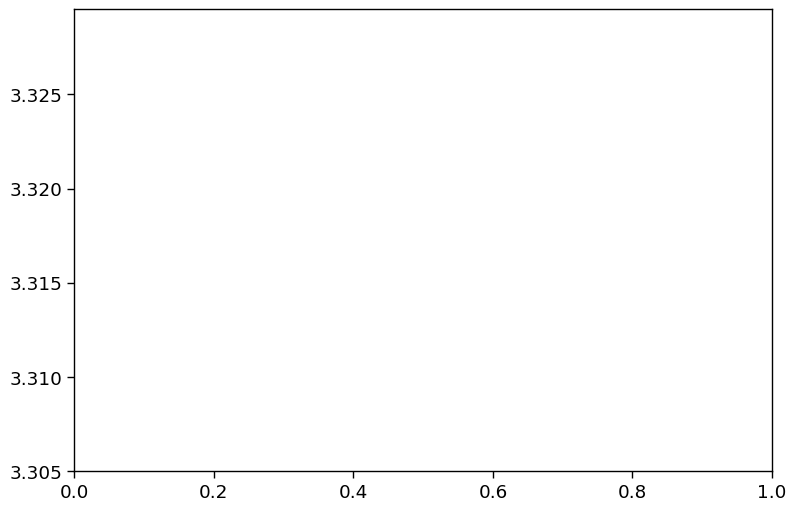

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths to your three datasets
paths = [
    Path("mf_ei_runs_hartmann_aggregate.csv"),
    # Path("mf_mes_runs_hartmann_aggregate.csv"),
    # Path("mf_kg_runs_hartmann_aggregate_12.csv"),
    Path("mf_nonmyo_runs_hartmann_heu_1.7_8_8.csv"),
    Path("mf_nonmyo_runs_hartmann_8_8.csv"),
    Path("mf_nonmyo_runs_hartmann_12_12.csv"),
    Path("mf_nonmyo_runs_hartmann_heu_1.7_12_12.csv"),
    Path("sf_ei_runs_hartmann_aggregate.csv"),
    # Path("sf_mes_runs_hartmann_aggregate.csv"),
    # Path("sf_kg_runs_hartmann_aggregate_12.csv"),
    Path("sf_nonmyo_runs_hartmann_8_8.csv"),
    Path("sf_nonmyo_runs_hartmann_12_12.csv")
]
TRUE_OPT   = 3.322  # max objective value

# Column names (as found in your files)
COST_COL = "cumulative_cost_mean"
MEAN_COL = "best_hi_mean"
STD_COL  = "best_hi_std"

plt.figure(figsize=(9, 6))
plt.ylim(3.3050, 3.3295)

for p in paths:
    df = pd.read_csv(p)

    # Coerce to numeric & sort by cost
    x = pd.to_numeric(df[COST_COL], errors="coerce")
    y = pd.to_numeric(df[MEAN_COL], errors="coerce")
    s = pd.to_numeric(df[STD_COL],  errors="coerce")
    sub = pd.DataFrame({"x": x, "y": y, "s": s}).dropna().sort_values("x")

    # Mean line + shaded band for ± std
    plt.plot(sub["x"].values, sub["y"].values, label = p.name)  # auto-assigns different colors
    plt.fill_between(
        sub["x"].values,
        (sub["y"] - sub["s"]).values,
        (sub["y"] + sub["s"]).values,
        alpha=0.2
    )

plt.axhline(TRUE_OPT, ls="--", label=f"True optimum = {TRUE_OPT}")
plt.xlabel("Cumulative cost")
plt.ylabel("Best observed mean ± std")
plt.title("Best observed performance vs cumulative cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'mf_nonmyo_runs_branin_heu_2.1_8_8.csv'

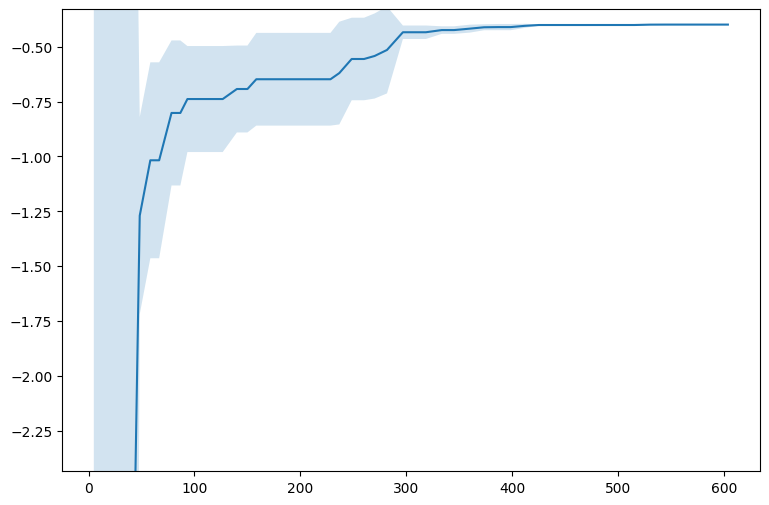

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths to your three datasets
paths = [
    Path("mf_ei_runs_branin_aggregate.csv"),
    # Path("mf_mes_runs_branin_aggregate.csv"),
    # Path("mf_kg_runs_branin_aggregate_12.csv"),
    Path("mf_nonmyo_runs_branin_12_12.csv"),
    # Path("mf_nonmyo_runs1_branin_12_12.csv"),
    # Path("mf_nonmyo_runs1_branin_8_8.csv"),
    # Path("mf_nonmyo_runs_branin_heu_2.0_8_8.csv"),
    Path("mf_nonmyo_runs_branin_heu_1.3_12_12.csv"),
    Path("sf_ei_runs_branin_aggregate.csv"),
    # Path("sf_mes_runs_branin_aggregate.csv"),
    # Path("sf_kg_runs_branin_aggregate_12.csv"),
    # # Path("sf_nonmyo_runs_branin_8_8.csv"),
    Path("sf_nonmyo_runs_branin_12_12.csv")
]
TRUE_OPT   = -0.398  # max objective value

# Column names (as found in your files)
COST_COL = "cumulative_cost_mean"
MEAN_COL = "best_hi_mean"
STD_COL  = "best_hi_std"

plt.figure(figsize=(9, 6))
plt.ylim(-2.43467, -0.32956)

for p in paths:
    df = pd.read_csv(p)

    # Coerce to numeric & sort by cost
    x = pd.to_numeric(df[COST_COL], errors="coerce")
    y = pd.to_numeric(df[MEAN_COL], errors="coerce")
    s = pd.to_numeric(df[STD_COL],  errors="coerce")
    sub = pd.DataFrame({"x": x, "y": y, "s": s}).dropna().sort_values("x")

    # Mean line + shaded band for ± std
    plt.plot(sub["x"].values, sub["y"].values, label=p.name)  # auto-assigns different colors
    plt.fill_between(
        sub["x"].values,
        (sub["y"] - sub["s"]).values,
        (sub["y"] + sub["s"]).values,
        alpha=0.2
    )
plt.axhline(TRUE_OPT, ls="--", label=f"True optimum = {TRUE_OPT}")
plt.xlabel("Cumulative cost")
plt.ylabel("Best observed mean ± std")
plt.title("Best observed performance vs cumulative cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

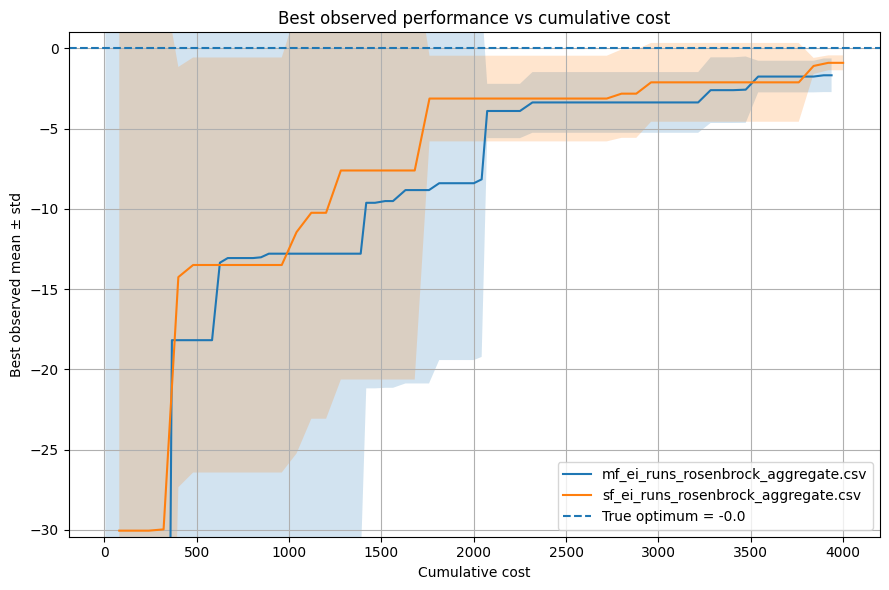

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths to your three datasets
paths = [
    Path("mf_ei_runs_rosenbrock_aggregate.csv"),
    # Path("mf_mes_runs_branin_aggregate.csv"),
    # Path("mf_kg_runs_branin_aggregate_12.csv"),
    # Path("mf_nonmyo_runs_branin_heu_2.1_8_8.csv"),
    # Path("mf_nonmyo_runs_branin_12_12.csv"),
    # Path("mf_nonmyo_runs1_branin_12_12.csv"),
    # Path("mf_nonmyo_runs1_branin_8_8.csv"),
    # Path("mf_nonmyo_runs_branin_heu_2.0_8_8.csv"),
    # Path("mf_nonmyo_runs_branin_heu_1.3_12_12.csv"),
    Path("sf_ei_runs_rosenbrock_aggregate.csv"),
    # Path("sf_mes_runs_branin_aggregate.csv"),
    # Path("sf_kg_runs_branin_aggregate_12.csv"),
    # Path("sf_nonmyo_runs_branin_8_8.csv"),
    # Path("sf_nonmyo_runs_branin_12_12.csv")
]
TRUE_OPT   = -0.00 # max objective value

# Column names (as found in your files)
COST_COL = "cumulative_cost_mean"
MEAN_COL = "best_hi_mean"
STD_COL  = "best_hi_std"

plt.figure(figsize=(9, 6))
plt.ylim(-30.43467, 1.0000)

for p in paths:
    df = pd.read_csv(p)

    # Coerce to numeric & sort by cost
    x = pd.to_numeric(df[COST_COL], errors="coerce")
    y = pd.to_numeric(df[MEAN_COL], errors="coerce")
    s = pd.to_numeric(df[STD_COL],  errors="coerce")
    sub = pd.DataFrame({"x": x, "y": y, "s": s}).dropna().sort_values("x")

    # Mean line + shaded band for ± std
    plt.plot(sub["x"].values, sub["y"].values, label=p.name)  # auto-assigns different colors
    plt.fill_between(
        sub["x"].values,
        (sub["y"] - sub["s"]).values,
        (sub["y"] + sub["s"]).values,
        alpha=0.2
    )
plt.axhline(TRUE_OPT, ls="--", label=f"True optimum = {TRUE_OPT}")
plt.xlabel("Cumulative cost")
plt.ylabel("Best observed mean ± std")
plt.title("Best observed performance vs cumulative cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

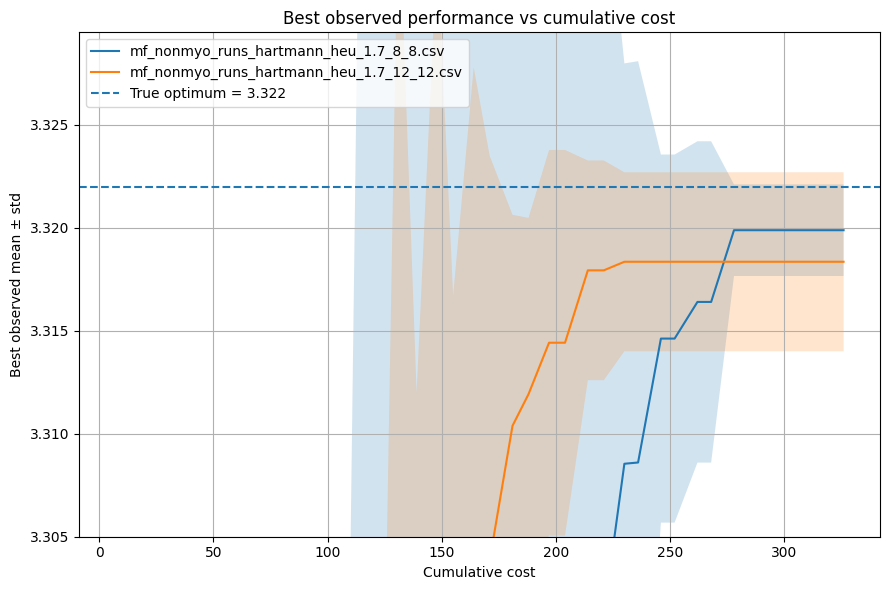

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths to your three datasets
paths = [
    # Path("mf_nonmyo_runs_hartmann_heu_1.3_8_8.csv"),
    Path("mf_nonmyo_runs_hartmann_heu_1.7_8_8.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.0_8_8.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.1_8_8.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.3_8_8.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.5_8_8.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.7_8_8.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_1.3_12_12.csv"),
    Path("mf_nonmyo_runs_hartmann_heu_1.7_12_12.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.0_12_12.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.3_12_12.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.5_12_12.csv"),
    # Path("mf_nonmyo_runs_hartmann_heu_2.7_12_12.csv"),

]
TRUE_OPT   = 3.322  # max objective value

# Column names (as found in your files)
COST_COL = "cumulative_cost_mean"
MEAN_COL = "best_hi_mean"
STD_COL  = "best_hi_std"

plt.figure(figsize=(9, 6))
plt.ylim(3.3050, 3.3295)

for p in paths:
    df = pd.read_csv(p)

    # Coerce to numeric & sort by cost
    x = pd.to_numeric(df[COST_COL], errors="coerce")
    y = pd.to_numeric(df[MEAN_COL], errors="coerce")
    s = pd.to_numeric(df[STD_COL],  errors="coerce")
    sub = pd.DataFrame({"x": x, "y": y, "s": s}).dropna().sort_values("x")

    # Mean line + shaded band for ± std
    plt.plot(sub["x"].values, sub["y"].values, label=p.name)  # auto-assigns different colors
    plt.fill_between(
        sub["x"].values,
        (sub["y"] - sub["s"]).values,
        (sub["y"] + sub["s"]).values,
        alpha=0.2
    )
plt.axhline(TRUE_OPT, ls="--", label=f"True optimum = {TRUE_OPT}")
plt.xlabel("Cumulative cost")
plt.ylabel("Best observed mean ± std")
plt.title("Best observed performance vs cumulative cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

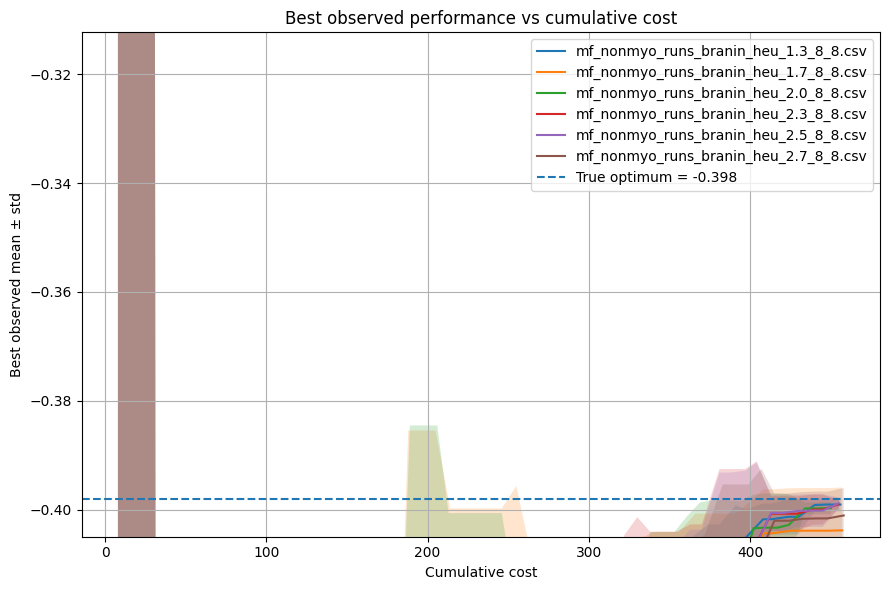

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Paths to your three datasets
paths = [
    Path("mf_nonmyo_runs_branin_heu_1.3_8_8.csv"),
    Path("mf_nonmyo_runs_branin_heu_1.7_8_8.csv"),
    Path("mf_nonmyo_runs_branin_heu_2.0_8_8.csv"),
    Path("mf_nonmyo_runs_branin_heu_2.3_8_8.csv"),
    Path("mf_nonmyo_runs_branin_heu_2.5_8_8.csv"),
    Path("mf_nonmyo_runs_branin_heu_2.7_8_8.csv"),
    # Path("mf_nonmyo_runs_branin_heu_1.3_12_12.csv"),
    # Path("mf_nonmyo_runs_branin_heu_1.7_12_12.csv"),
    # Path("mf_nonmyo_runs_branin_heu_2.0_12_12.csv"),
    # Path("mf_nonmyo_runs_branin_heu_2.3_12_12.csv"),
    # Path("mf_nonmyo_runs_branin_heu_2.5_12_12.csv"),
    # Path("mf_nonmyo_runs_branin_heu_2.7_12_12.csv"),

]
TRUE_OPT   = -0.398  # max objective value

# Column names (as found in your files)
COST_COL = "cumulative_cost_mean"
MEAN_COL = "best_hi_mean"
STD_COL  = "best_hi_std"

plt.figure(figsize=(9, 6))
plt.ylim(-0.4050, -0.3123)

for p in paths:
    df = pd.read_csv(p)

    # Coerce to numeric & sort by cost
    x = pd.to_numeric(df[COST_COL], errors="coerce")
    y = pd.to_numeric(df[MEAN_COL], errors="coerce")
    s = pd.to_numeric(df[STD_COL],  errors="coerce")
    sub = pd.DataFrame({"x": x, "y": y, "s": s}).dropna().sort_values("x")

    # Mean line + shaded band for ± std
    plt.plot(sub["x"].values, sub["y"].values, label=p.name)  # auto-assigns different colors
    plt.fill_between(
        sub["x"].values,
        (sub["y"] - sub["s"]).values,
        (sub["y"] + sub["s"]).values,
        alpha=0.2
    )
plt.axhline(TRUE_OPT, ls="--", label=f"True optimum = {TRUE_OPT}")
plt.xlabel("Cumulative cost")
plt.ylabel("Best observed mean ± std")
plt.title("Best observed performance vs cumulative cost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# # --- run once per session ---
# from pathlib import Path
# ONEDRIVE = Path.home() / "OneDrive" /  "WORK_PHD"  # adjust once
# ONEDRIVE.mkdir(parents=True, exist_ok=True)        # assure the folder exists
# %cd $ONEDRIVE
# print("Kernel working dir:", ONEDRIVE)
